# Arc Diagram of Intra-atomic Interactions

**What this notebook does:**
- Reads contact-map CSV files (one per simulation, named `<sim>_contact_matrix_analysis.csv`)
  from the simulation root directory
- Plots an **arc diagram** for each simulation using the `arcplot` library,
  showing intra-atomic interactions as arcs between residues
- Saves each arc diagram as a PNG file

**Prerequisites:**
Contact-map CSV files of intra-atomic contacts must be present.

**Sections:**
1. Install & import libraries
2. Configuration (paths)
3. Discover contact-map files
4. Plot and save arc diagrams


In [1]:
# 1. Install required libraries
!pip install arcplot

In [2]:
# 2. Imports
import os
import numpy as np
from pathlib import Path
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math

from arcplot import ArcDiagram, show_arc_plot, save_arc_plot_as

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 3. Configuration
ROOTDIR    = '/content/drive/MyDrive/M1_STAGE/Data/'
OUTPUT_DIR = Path('/content/drive/MyDrive/M1_STAGE/Manips/Figures/')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

os.chdir(ROOTDIR)

ENV25 = [20,21,22,23,24,25,26,27]
ENV124 = [119,120,121,122,123,124,125,126]
ENV50 = [45,46,47,48,49,50,51,52,53,54,55]
ENV149 = [144,145,146,147,148,149,150,151,152,153,154]


In [4]:
# 4. Discover contact-map files
contact_maps_paths = []
for subdir, _, files in os.walk(ROOTDIR):
    for f in files:
        if f.endswith('contact_matrix_analysis.csv'):
            contact_maps_paths.append(os.path.join(subdir, f))

contact_maps_paths.sort()
print(f'Found {len(contact_maps_paths)} contact map file(s).')

all_relevant_nodes_set = set()
for sim_path in contact_maps_paths:
    df_temp = pd.read_csv(sim_path)

    # Filter connections where either Residue1 or Residue2 is in env_25 or env_124
    filtered_df = df_temp[
        (df_temp['Residue1'].isin(ENV25)) |
        (df_temp['Residue2'].isin(ENV25)) |
        (df_temp['Residue1'].isin(ENV124)) |
        (df_temp['Residue2'].isin(ENV124))
    ]

    all_relevant_nodes_set.update(filtered_df['Residue1'].unique())
    all_relevant_nodes_set.update(filtered_df['Residue2'].unique())

global_nodes = sorted(list(all_relevant_nodes_set))

Found 6 contact map file(s).


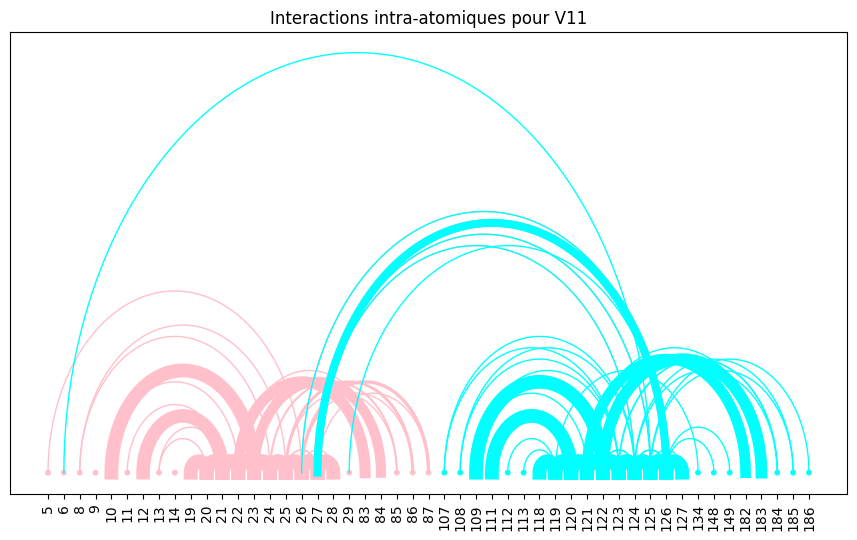

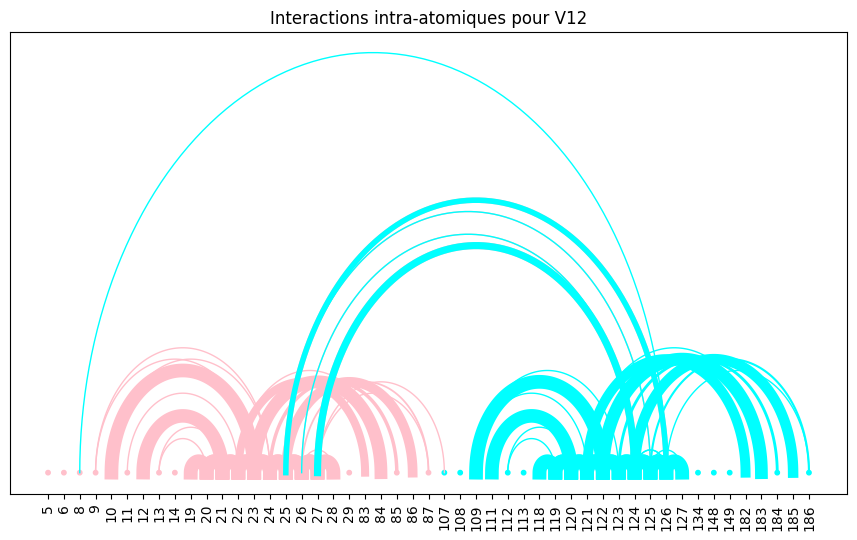

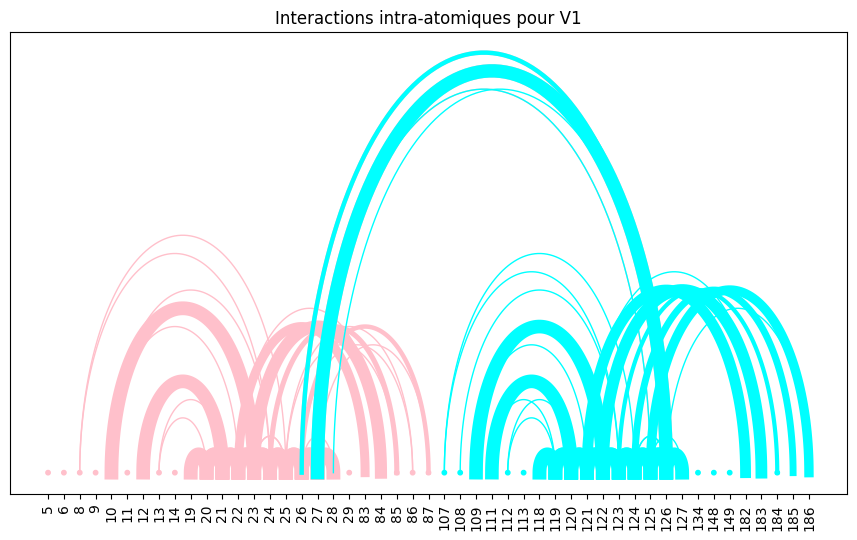

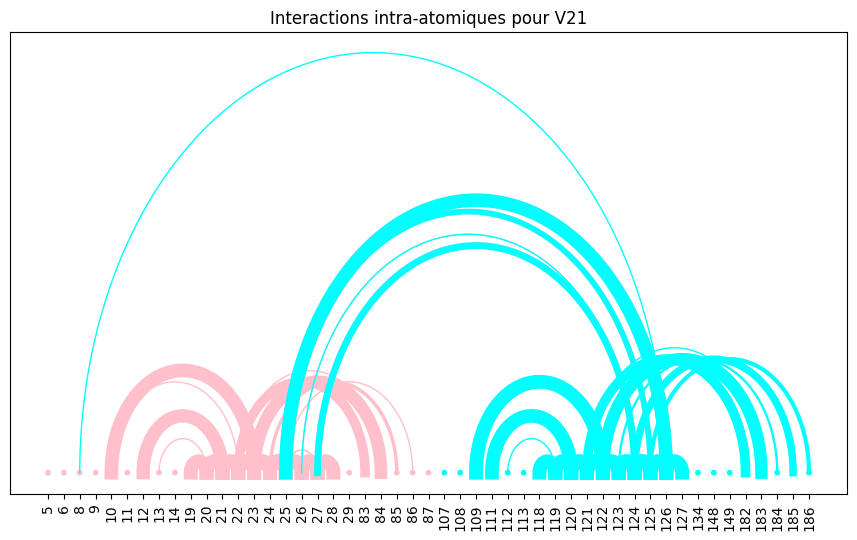

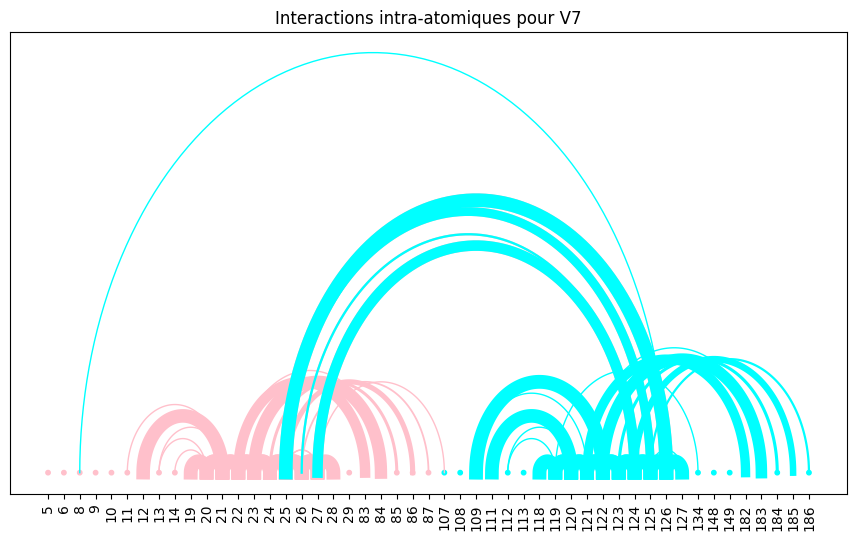

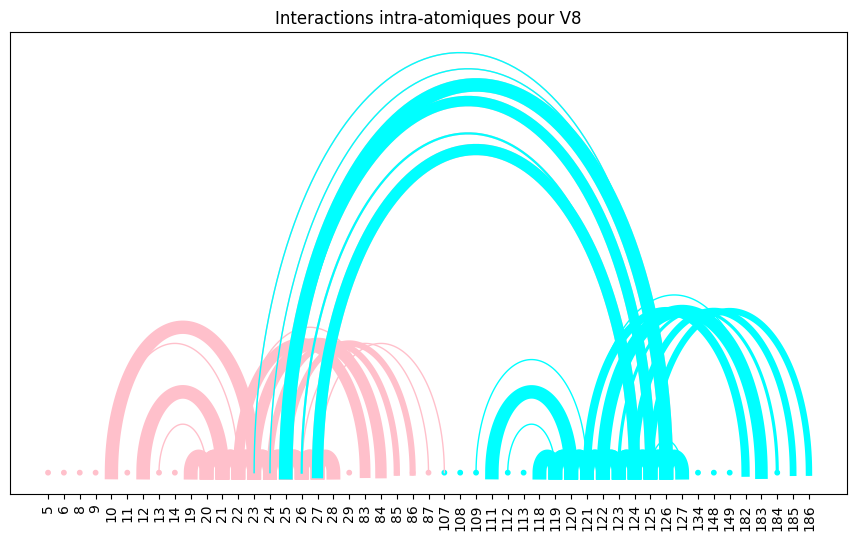

In [5]:
# 5. Plot and save arc diagrams
for sim in contact_maps_paths:
    sim_name = os.path.normpath(sim).split('/')[-1]
    sim_name = sim_name.replace("_contact_matrix_analysis.csv", "")
    df_sim = pd.read_csv(sim);

    # Filter df_sim directly to get all relevant connections for env_25 and env_124
    # This replaces the inner loop and dictionary creation for df_env_25 and df_env_124
    df_env_25 = df_sim[df_sim['Residue1'].isin(ENV25)].copy();
    df_env_124 = df_sim[df_sim['Residue1'].isin(ENV124)].copy() # Assuming env_124 also filters by 'Residue1'
    #df_env_50 = df_sim[df_sim['Residue1'].isin(env_50)].copy()
    #df_env_149 = df_sim[df_sim['Residue1'].isin(env_149)].copy()

    title = (f'Interactions intra-atomiques pour {sim_name}');
    p = Path(OUTPUT_DIR).parent.joinpath(f"{sim_name}_arcgraph.png");

    #concatenate env df into one df:
    df = pd.concat([df_env_25, df_env_124])#,df_env_50,df_env_149

    # The global_nodes list is now calculated once before the loop
    # current_nodes is not needed if we want universal labels

    custom_colors = [];
    for residue in global_nodes: # Use the pre-calculated global_nodes for coloring
        if residue > 100:
            color = 'cyan'
        else:
            color = 'pink'
        custom_colors.append(color);

    arc_diagram = ArcDiagram(global_nodes, title);
    for connection in df.iterrows():
        arc_diagram.connect(
            int(connection[1]['Residue1']),
            int(connection[1]['Residue2']),
            linewidth=(connection[1]['Frequency']*10)
        );
    height = 6;
    arc_diagram.set_custom_colors(custom_colors);
    arc_diagram.set_background_color("white");
    arc_diagram.set_label_rotation_degree(90);
    arc_diagram.save_plot_as(file_name=p,
                                node_size=10,
                                resolution=100,
                                height=height,
                                width=height*1.8
                                );

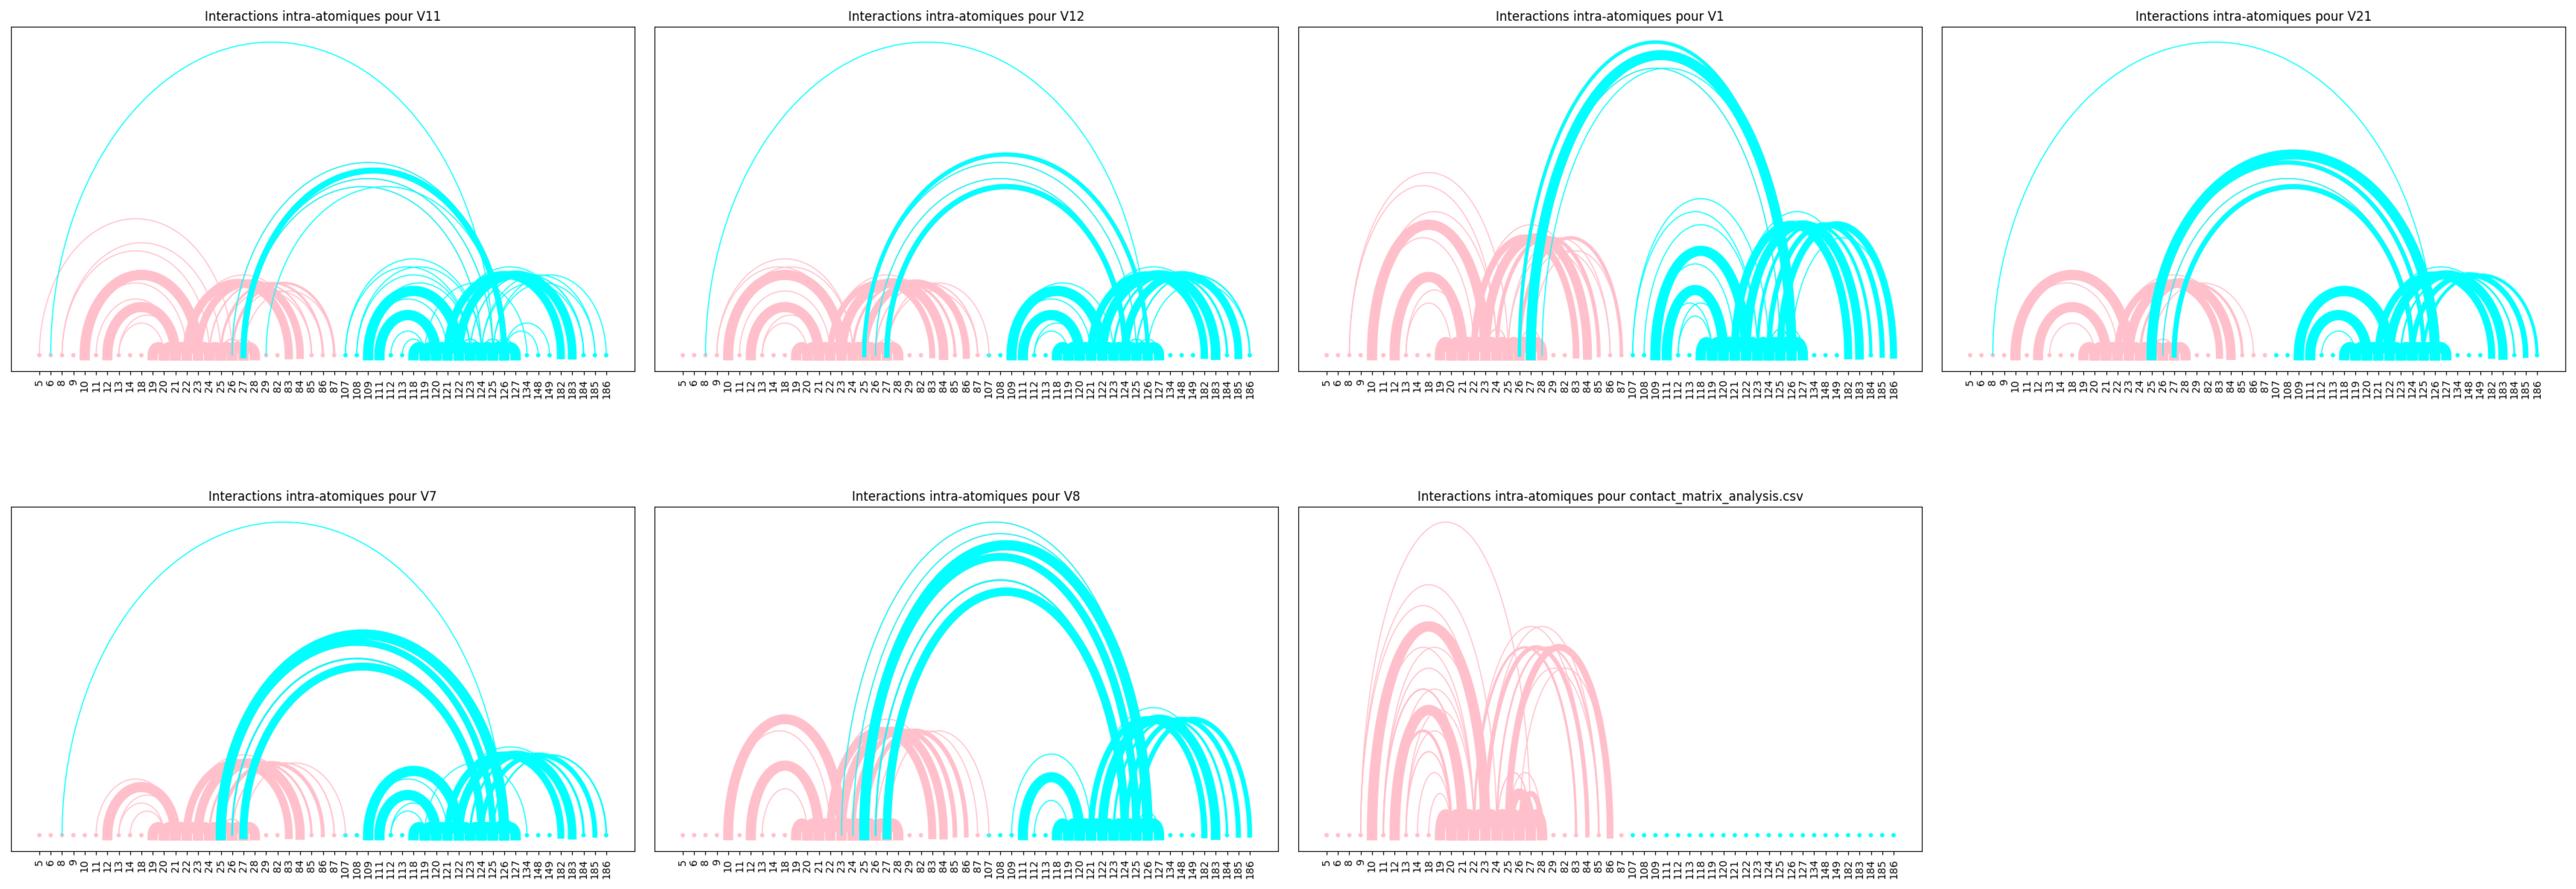

In [6]:
# 6. Unite all diagrams in one plot
# Find all generated arc plot image files
image_paths = sorted(list(OUTPUT_DIR.glob('*_arcgraph.png')))

num_plots = len(image_paths)

# Determine optimal grid size for subplots
rows = 2
cols = int(math.ceil(num_plots / rows))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 18, rows * 14))
# Flatten the axes array for easier iteration, handles both 1D and 2D arrays
axes = axes.flatten()

for i, img_path in enumerate(image_paths):
    img = mpimg.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis('off') # Hide axes ticks and labels for cleaner image display

# Hide any unused subplots if the grid is not perfectly filled
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()
